# 10-5 VGG for cifar10

## original code is =>
https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#sphx-glr-beginner-blitz-cifar10-tutorial-py

In [1]:
import torch
import torch.nn as nn

import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [13]:
from torch.utils.tensorboard import SummaryWriter 

writer = SummaryWriter(log_dir='runs/vgg_cifar10')

## define loss tracker

현재 loss 값을 TensorBoard 에 기록


In [6]:
def loss_tracker(loss_tag, loss_value, num):
# 3개의 입력
    #loss_tag = 그래프 이름
    #loss_value = 현재 loss 값
    #num = 현재 iteration 번호
    writer.add_scalar(loss_tag, loss_value.item(), int(num.item()))

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)
if device =='cuda':
    torch.cuda.manual_seed_all(777)

- transforms.Compose
    - 여러 개의 transform을 순서대로 적용
        - transforms.ToTensor() : 
            - numpy / PIL 이미지를 Tensor로 변환 : (H, W, C) -> (C, H, W)
            - 픽셀 값을 0~1로 정규화
        - transforms.Normalize :
            - 데이터를 정규화
            - $$input = \frac{input - mean}{std}$$

In [8]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
# mean = (0.5, 0.5, 0.5) std  = (0.5, 0.5, 0.5)

trainset = torchvision.datasets.CIFAR10(root='./cifar10', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./cifar10', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

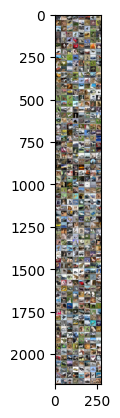

  cat  deer   car   car


In [12]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     
    # unnormalize
    # -1 ~ 1의 값을 다시 0 ~ 1 범위로 되돌려 정상적인 색상을 찾게 한다.
    npimg = img.numpy()
    # 파이토치 텐서를 시각화 도구인 matplotlib이 이해할 수 있는 Numpy 배열로 변환한다.
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    # 파이토치는 차원 순서가 (채널, 가로, 세로) 인데 다시 이것을 (가로,세로,채널)로 변경
    plt.show()


# get some random training images
dataiter = iter(trainloader)
# trainloader : 5만 장의 CIFAR-10 데이터를 512장씩 묶어서 배달
images, labels = next(dataiter)
writer.add_images('train_images', images/2 + 0.5)

# show images
imshow(torchvision.utils.make_grid(images))

# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

## make VGG16 using vgg.py

In [ ]:
import vgg
#vgg.py 파일 전체를 모듈로 불러오기
#import torchvision.models.vgg as vgg

In [11]:
cfg = [32,32,'M', 64,64,128,128,128,'M',256,256,256,512,512,512,'M'] #13 + 3 =vgg16

In [ ]:
class VGG(nn.Module):
    
    def __init__(self, features, num_classes=1000, init_weights=True):
        super(VGG, self).__init__()
        
        self.features = features #convolution
        # nn.Sequential(*layers) 객체가 VGG 클래스의 features 변수로 들어간다.

        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )#FC layer -> 총 층의 개수는 3개
        
        if init_weights:
            self._initialize_weights()

    def forward(self, x):
        x = self.features(x) #Convolution 
        x = self.avgpool(x) # avgpool
        x = x.view(x.size(0), -1) 
        # VGG 모델에서 avgpool을 통과한 데이터의 모양이 (32, 512, 7, 7)이라고 가정
        # x.size(0)은 32가 된다.
        # 512 * 7 * 7 = 25,088
        # x.view(32, -1)을 실행하면, 결과적으로 데이터의 모양은 (32, 25088) 이다.
        x = self.classifier(x) #FC layer
        return x

    def _initialize_weights(self):
        for m in self.modules():
            # __init__ 함수 안에서 정의한 self.features, self.classifier 등을 조사함
            if isinstance(m, nn.Conv2d):
            # isinstance(object, class) : 특정 객체가 어떤 클래스의 인스턴스인지 확인
                # m: 검사 대상 (현재 for 루프에서 꺼내온 레이어 부품)
                # nn.Conv2d: 기준 (컨볼루션 레이어라는 규격)
                # 결과: 맞으면 True, 아니면 False를 반환
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                # mode='fan_out': 출력 뉴런의 개수를 고려하여 가중치의 분산을 조절한다.
                if m.bias is not None: # 편향이 있다면 0으로 초기화
                    nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
                
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
            # y = wx + b
            # 가중치를 정규분포(normal distribution) 로 초기화
            # 평균(mean) = 0
            # 표준편차(std) = 0.01

In [ ]:
# cfg = [32,32,'M', 64,64,128,128,128,'M',256,256,256,512,512,512,'M']

In [17]:
vgg16= VGG(vgg.make_layers(cfg),10,True).to(device)

In [19]:
print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (16): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=

In [18]:
a=torch.Tensor(1,3,32,32).to(device)
out = vgg16(a)
print(out)

tensor([[-1.5805e+34, -3.8938e+34, -1.3562e+34, -2.2280e+34, -3.4630e+33,
          1.6619e+34, -2.6135e+34, -3.5845e+33, -1.4463e+34,  1.2230e+33]],
       grad_fn=<AddmmBackward0>)


In [ ]:
criterion = nn.CrossEntropyLoss().to(device)

optimizer = torch.optim.SGD(vgg16.parameters(), lr = 0.005,momentum=0.9)

lr_sche = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.9)
# 학습이 진행됨에 따라 학습률을 점점 줄여준다.
# 5에포크 마다 한번씩
# 기존 학습률에 0.9를 곱해서 조금씩 보폭을 줄인다.

## make plot

In [21]:
loss_plt = 'loss_tracker'

## training

In [22]:
print(len(trainloader))
# 전체 데이터 : 50,000장(CIFAR-10 학습용)
# 배치 사이즈 : 512장
epochs = 50

for epoch in range(epochs):  # loop over the dataset multiple times
    running_loss = 0.0
    lr_sche.step()
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = vgg16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 30 == 29:    # print every 30 mini-batches
            loss_tracker(loss_plt, torch.Tensor([running_loss/30]), torch.Tensor([i + epoch*len(trainloader) ]))
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 30))
            running_loss = 0.0
        

print('Finished Training')

98


C:\Users\hhnur\AppData\Local\Temp\ipykernel_35104\2069436170.py:6: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  lr_sche.step()


[1,    30] loss: 2.301
[1,    60] loss: 2.292
[1,    90] loss: 2.241
[2,    30] loss: 2.046
[2,    60] loss: 1.905
[2,    90] loss: 1.803
[3,    30] loss: 1.725
[3,    60] loss: 1.683
[3,    90] loss: 1.657
[4,    30] loss: 1.569
[4,    60] loss: 1.547
[4,    90] loss: 1.502
[5,    30] loss: 1.411
[5,    60] loss: 1.424
[5,    90] loss: 1.383
[6,    30] loss: 1.349
[6,    60] loss: 1.287


KeyboardInterrupt: 

In [ ]:
dataiter = iter(testloader)
images, labels = dataiter.next()

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [ ]:
outputs = vgg16(images.to(device))

In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))

In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = vgg16(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

In [ ]:
writer.close()